# Jigsaw Solver: Image Reconstruction from Shuffled Tiles
**Algorithms:** Hill Climbing and Simulated Annealing (AIMA, Fig. 4.2)

**Idea**
- Cut an image into a `GRID x GRID` set of tiles and shuffle them.
- A **state** is a permutation: `state[position] = tile_id`.
- A **successor** of a state is obtained by **swapping two tiles**.
- `VALUE(state)` = minus the total *edge mismatch* between every pair of tiles that touch in the layout. Better-fitting edges means a higher value, and the solved puzzle should have (near) the highest value.

**Notebook outline**
1. Setup and image loading
2. Tiles and edge compatibility (the VALUE function)
3. Hill Climbing (steepest ascent, plus random restarts)
4. Simulated Annealing
5. Run and compare
6. Benchmark over puzzle sizes and seeds

In [61]:
import itertools, math, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------- CONFIG -------------------------
IMAGE_PATH = "C:/Users/Cipher/OneDrive/Pictures/bird.jpg"   # "C:/Users/Cipher/OneDrive/Pictures/1789890987021.jpg"    #"C:/Users/Cipher/OneDrive/Pictures/Deer.jpg"     # e.g. "my_photo.jpg". None -> built-in sample image
GRID       = 4        # puzzle is GRID x GRID tiles (try 4, 5, 6, 8)
IMG_SIZE   = 384      # image is resized to about IMG_SIZE x IMG_SIZE
SEED       = 42
# ----------------------------------------------------------

rng = np.random.default_rng(SEED)
IMG_SIZE = (IMG_SIZE // GRID) * GRID      # make it divisible by GRID
N = GRID * GRID
print(f"{GRID}x{GRID} puzzle -> {N} tiles, {math.factorial(N):.2e} possible arrangements")

4x4 puzzle -> 16 tiles, 2.09e+13 possible arrangements


## 1. Load the image

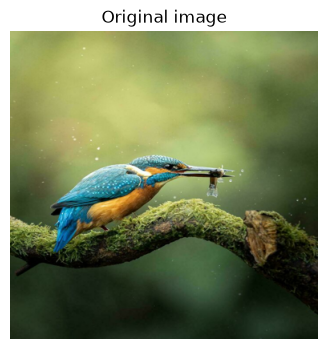

In [62]:
def synthetic_image(size, rng):
    # Fallback sample image (landscape) used if no image is available.
    y, x = np.mgrid[0:size, 0:size] / size
    img = np.zeros((size, size, 3))
    img[..., 0] = 90 + 120 * y
    img[..., 1] = 150 + 80 * y
    img[..., 2] = 255 - 90 * y
    img[(x - 0.75) ** 2 + (y - 0.22) ** 2 < 0.015] = (255, 220, 60)   # sun
    img[y > 0.62 + 0.08 * np.sin(6 * x + 1)] = (40, 140, 70)           # far hills
    img[y > 0.75 + 0.06 * np.sin(9 * x + 4)] = (20, 90, 50)            # near hills
    img += 12 * np.sin(40 * x * y + 25 * x)[..., None]                 # texture
    img += rng.normal(0, 4, img.shape)
    return np.clip(img, 0, 255).astype(np.uint8)


def load_image(path, size, rng):
    if path is not None:
        return np.array(Image.open(path).convert("RGB").resize((size, size)))
    try:
        from skimage import data
        return np.array(Image.fromarray(data.astronaut()).resize((size, size)))
    except Exception:
        return synthetic_image(size, rng)


image = load_image(IMAGE_PATH, IMG_SIZE, rng)
plt.figure(figsize=(4, 4)); plt.imshow(image); plt.axis("off"); plt.title("Original image"); plt.show()

## 2. Tiles, shuffling and the VALUE function

**Edge compatibility.** For two tiles `i` (left) and `j` (right) we measure how well the right edge of `i` continues into the left edge of `j`. We use a *prediction-based* dissimilarity: extrapolate each tile's last two pixel columns one step and compare with the neighbour's actual border column (same for top/bottom). This is more robust than comparing raw border pixels.

We precompute two `N x N` matrices:
- `right[i, j]`: cost of placing tile `j` immediately to the **right** of tile `i`
- `down[i, j]`: cost of placing tile `j` immediately **below** tile `i`

so evaluating any arrangement is just a few table look-ups.

cost of TRUE arrangement : 2.13
cost of shuffled state   : 25.69


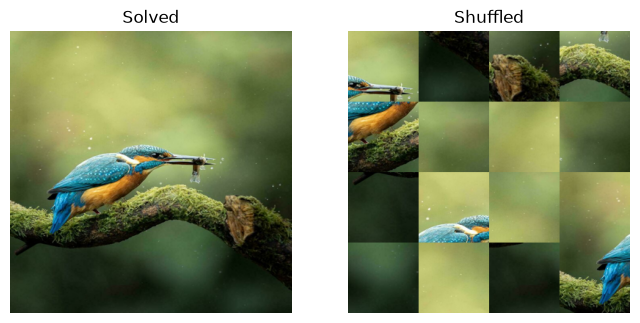

In [63]:
def split_tiles(img, g):
    t = img.shape[0] // g
    return np.array([img[r*t:(r+1)*t, c*t:(c+1)*t] for r in range(g) for c in range(g)])


def assemble(tiles, perm, g):
    t = tiles.shape[1]
    out = np.zeros((g * t, g * t, 3), dtype=np.uint8)
    for pos, tile_id in enumerate(perm):
        r, c = divmod(pos, g)
        out[r*t:(r+1)*t, c*t:(c+1)*t] = tiles[tile_id]
    return out


def _edge_cost(last, prev, first, second):
    # last/prev: last two lines of tile A, first/second: first two lines of tile B.  Shapes (N, t, 3)
    pred_fwd = 2 * last - prev            # A extrapolated into B
    pred_bwd = 2 * first - second         # B extrapolated into A
    c1 = np.abs(pred_fwd[:, None] - first[None]).sum(axis=(2, 3))
    c2 = np.abs(last[:, None] - pred_bwd[None]).sum(axis=(2, 3))
    return c1 + c2


def compat_matrices(tiles):
    T = tiles.astype(np.float64)
    right = _edge_cost(T[:, :, -1], T[:, :, -2], T[:, :, 0], T[:, :, 1])   # columns
    down  = _edge_cost(T[:, -1, :], T[:, -2, :], T[:, 0, :], T[:, 1, :])   # rows
    off = ~np.eye(len(T), dtype=bool)
    scale = np.median(np.concatenate([right[off], down[off]]))
    return right / scale, down / scale      # normalised: typical mismatch ~ 1


class JigsawProblem:
    # state = permutation array, state[position] = tile_id
    def __init__(self, tiles, grid):
        self.g, self.n = grid, grid * grid
        self.right, self.down = compat_matrices(tiles)

    def cost(self, s):
        gr = s.reshape(self.g, self.g)
        return self.right[gr[:, :-1], gr[:, 1:]].sum() + self.down[gr[:-1, :], gr[1:, :]].sum()

    def value(self, s):                     # VALUE(state): higher is better
        return -self.cost(s)

    def random_state(self, rng):
        return rng.permutation(self.n)

    # ---- evaluation helpers (need the ground truth: identity permutation) ----
    def tiles_in_place(self, s):
        return float(np.mean(s == np.arange(self.n)))

    def neighbours_correct(self, s):
        gr, g = s.reshape(self.g, self.g), self.g
        h = (gr[:, 1:] == gr[:, :-1] + 1) & (gr[:, :-1] % g != g - 1)
        v = (gr[1:, :] == gr[:-1, :] + g)
        return float((h.sum() + v.sum()) / (h.size + v.size))


tiles = split_tiles(image, GRID)
problem = JigsawProblem(tiles, GRID)

solved = np.arange(N)
shuffled = problem.random_state(rng)
print("cost of TRUE arrangement :", round(problem.cost(solved), 2))
print("cost of shuffled state   :", round(problem.cost(shuffled), 2))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(assemble(tiles, solved, GRID));   ax[0].set_title("Solved");   ax[0].axis("off")
ax[1].imshow(assemble(tiles, shuffled, GRID)); ax[1].set_title("Shuffled"); ax[1].axis("off")
plt.show()

## 3. Hill Climbing
Direct implementation of the textbook pseudocode (steepest ascent):

```
current <- problem.INITIAL
while true:
    neighbor <- highest-valued successor of current
    if VALUE(neighbor) <= VALUE(current): return current
    current <- neighbor
```
Here the successors of a state are **all** `N(N-1)/2` pairwise swaps. Hill climbing gets stuck in **local maxima**, so we also provide *random-restart* hill climbing.

In [64]:
def hill_climbing(problem, init):
    current = init.copy()
    cur_val = problem.value(current)
    history = [cur_val]
    pairs = list(itertools.combinations(range(problem.n), 2))
    while True:
        best_val, best_pair = -np.inf, None
        for i, j in pairs:                                  # examine every successor
            current[i], current[j] = current[j], current[i]
            v = problem.value(current)
            current[i], current[j] = current[j], current[i]
            if v > best_val:
                best_val, best_pair = v, (i, j)
        if best_val <= cur_val:                             # local maximum reached
            return current, history
        i, j = best_pair
        current[i], current[j] = current[j], current[i]
        cur_val = best_val
        history.append(cur_val)


def hill_climbing_restarts(problem, n_restarts, rng):
    best, best_val, finals = None, -np.inf, []
    for _ in range(n_restarts):
        s, hist = hill_climbing(problem, problem.random_state(rng))
        finals.append(hist[-1])
        if hist[-1] > best_val:
            best, best_val = s, hist[-1]
    return best, best_val, finals

## 4. Simulated Annealing
Pseudocode from the figure:

```
for t = 1 to infinity:
    T <- schedule(t)
    if T = 0: return current
    next <- random successor of current
    dE <- VALUE(next) - VALUE(current)
    if dE > 0: current <- next
    else:      current <- next only with probability e^(dE/T)
```
> **Note on the sign:** the figure defines `ΔE = VALUE(current) − VALUE(next)` but then accepts when `ΔE > 0` and uses `e^(−ΔE/T)`; that is the textbook's energy (minimisation) convention mixed with the value (maximisation) convention. For a *value* we want to maximise, the consistent version is `ΔE = VALUE(next) − VALUE(current)`, accept if `ΔE > 0`, else accept with probability `e^(ΔE/T)`. That is what is implemented below.

**Cooling schedule:** exponential, `T(t) = T0 * alpha^t`.
- `T0` is auto-calibrated as the average |ΔE| of random swaps, so early on most moves are accepted.
- `alpha` is chosen so that the temperature reaches `T_min` after `n_steps`.

In [65]:
def estimate_T0(problem, rng, samples=300):
    s = problem.random_state(rng)
    base, deltas = problem.value(s), []
    for _ in range(samples):
        i, j = rng.choice(problem.n, 2, replace=False)
        s[i], s[j] = s[j], s[i]
        deltas.append(abs(problem.value(s) - base))
        s[i], s[j] = s[j], s[i]
    return float(np.mean(deltas))


def simulated_annealing(problem, init, rng, n_steps=100_000, T0=None, T_min=0.01, n_snapshots=5):
    if T0 is None:
        T0 = estimate_T0(problem, rng)
    alpha = (T_min / T0) ** (1.0 / n_steps)
    schedule = lambda t: T0 * alpha ** t                    # exponential cooling

    n = problem.n
    I = rng.integers(0, n, n_steps)                         # pre-drawn random numbers (fast)
    J = (I + rng.integers(1, n, n_steps)) % n               # j != i
    U = rng.random(n_steps)

    current = init.copy()
    cur_val = problem.value(current)
    history, temps, snaps = [], [], []
    snap_at = set(np.linspace(1, n_steps, n_snapshots).astype(int).tolist())
    accepted = 0

    for t in range(1, n_steps + 1):
        T = schedule(t)
        if T < T_min:                                       # (textbook: T == 0)
            break
        i, j = I[t - 1], J[t - 1]
        current[i], current[j] = current[j], current[i]     # random successor
        new_val = problem.value(current)
        dE = new_val - cur_val
        if dE > 0 or U[t - 1] < math.exp(dE / T):           # accept
            cur_val = new_val
            accepted += 1
        else:                                               # reject -> undo the swap
            current[i], current[j] = current[j], current[i]
        history.append(cur_val)
        temps.append(T)
        if t in snap_at:
            snaps.append((t, T, current.copy()))

    info = dict(history=np.array(history), temps=np.array(temps), snaps=snaps,
                T0=T0, alpha=alpha, acceptance=accepted / max(1, len(history)))
    return current, info

## 5. Run both algorithms and compare

In [66]:
def report(name, s, secs):
    return dict(name=name, cost=problem.cost(s), in_place=problem.tiles_in_place(s),
                nbrs=problem.neighbours_correct(s), secs=secs)

results, states = [], {}
rng_run = np.random.default_rng(SEED + 1)
start = shuffled.copy()

# --- Hill Climbing (single run from the shuffled state)
t0 = time.time()
hc_state, hc_hist = hill_climbing(problem, start)
results.append(report("Hill Climbing (1 run)", hc_state, time.time() - t0)); states[results[-1]["name"]] = hc_state

# --- Hill Climbing with random restarts
t0 = time.time()
hcr_state, hcr_val, hcr_finals = hill_climbing_restarts(problem, 20, rng_run)
results.append(report("Hill Climbing (20 restarts)", hcr_state, time.time() - t0)); states[results[-1]["name"]] = hcr_state

# --- Simulated Annealing
t0 = time.time()
sa_state, sa_info = simulated_annealing(problem, start, rng_run, n_steps=10002 * N)
results.append(report("Simulated Annealing", sa_state, time.time() - t0)); states[results[-1]["name"]] = sa_state

# --- Hybrid: SA followed by a hill-climbing polish
t0 = time.time()
pol_state, _ = hill_climbing(problem, sa_state)
results.append(report("SA + Hill-Climb polish", pol_state, time.time() - t0)); states[results[-1]["name"]] = pol_state

true_cost = problem.cost(solved)
print(f"{'Method':30s} {'cost':>9s} {'tiles in place':>15s} {'correct nbrs':>13s} {'time(s)':>8s}")
for r in results:
    print(f"{r['name']:30s} {r['cost']:9.2f} {r['in_place']*100:14.1f}% {r['nbrs']*100:12.1f}% {r['secs']:8.2f}")
print(f"{'(true arrangement)':30s} {true_cost:9.2f}")
print(f"\nSA: T0={sa_info['T0']:.3f}, alpha={sa_info['alpha']:.6f}, acceptance rate={sa_info['acceptance']*100:.1f}%")

Method                              cost  tiles in place  correct nbrs  time(s)
Hill Climbing (1 run)              10.53           31.2%         41.7%     0.01
Hill Climbing (20 restarts)         2.13          100.0%        100.0%     0.20
Simulated Annealing                 4.52            0.0%         83.3%     1.46
SA + Hill-Climb polish              4.52            0.0%         83.3%     0.00
(true arrangement)                  2.13

SA: T0=1.395, alpha=0.999969, acceptance rate=6.3%


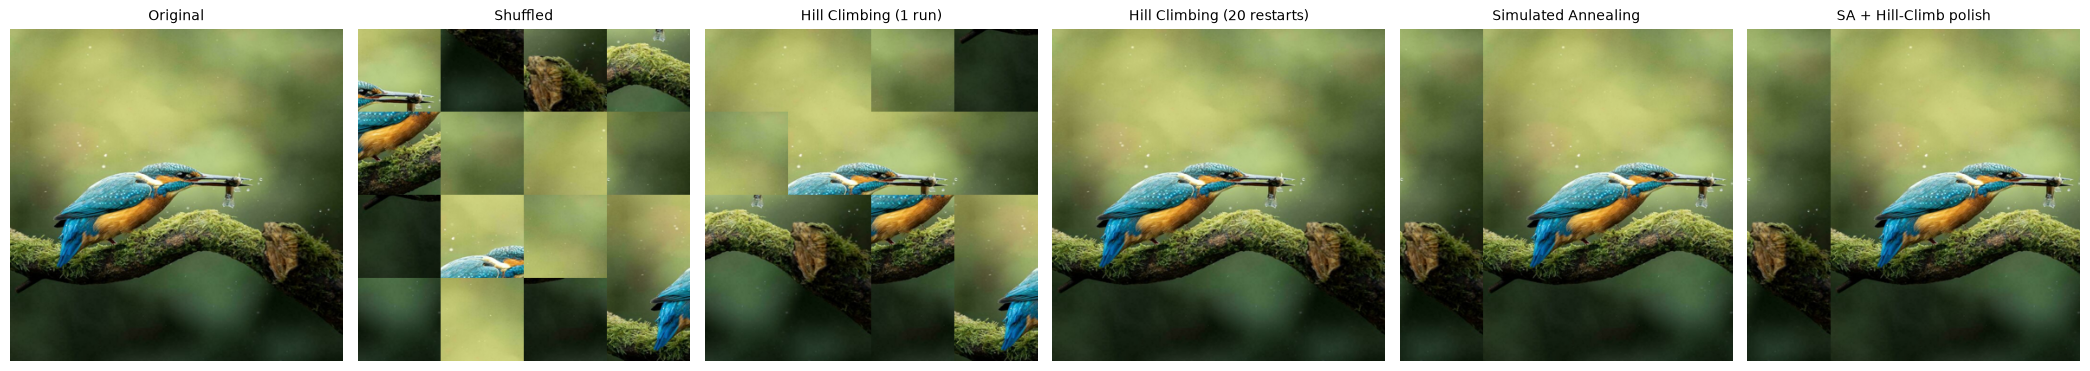

In [67]:
# ---- Visual comparison
fig, axes = plt.subplots(1, 6, figsize=(21, 4))
panels = [("Original", assemble(tiles, solved, GRID)), ("Shuffled", assemble(tiles, start, GRID))]
panels += [(r["name"], assemble(tiles, states[r["name"]], GRID)) for r in results[:3]] + \
          [(results[3]["name"], assemble(tiles, states[results[3]["name"]], GRID))]
panels = panels[:6]
for ax, (title, im) in zip(axes, panels):
    ax.imshow(im); ax.axis("off"); ax.set_title(title, fontsize=10)
plt.tight_layout(); plt.show()

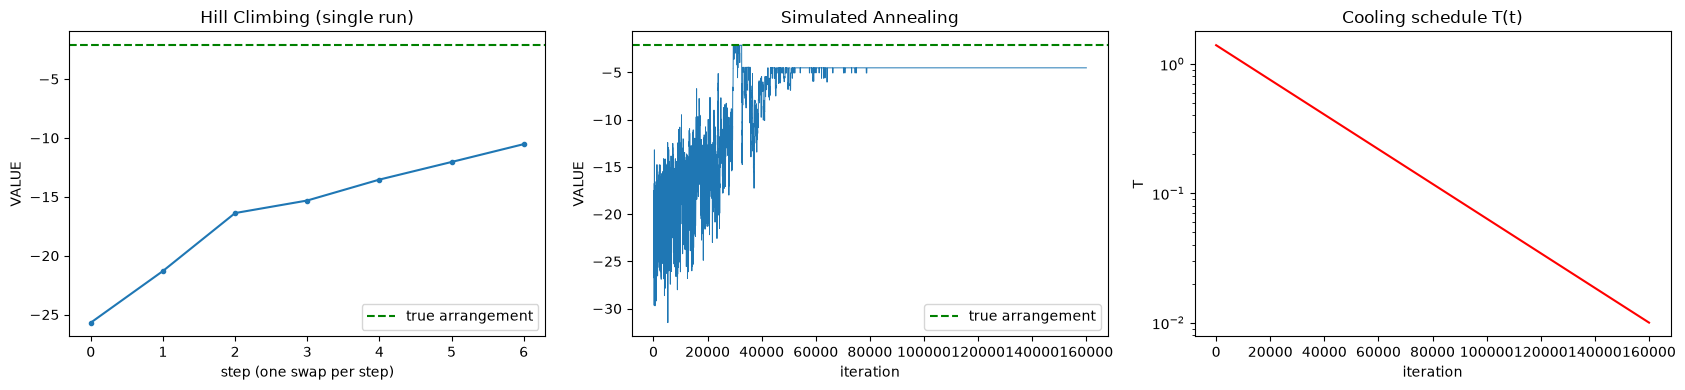

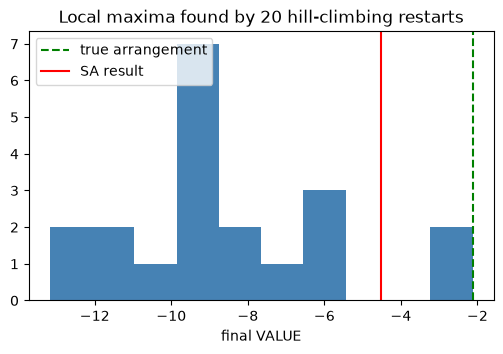

In [68]:
# ---- Convergence curves
fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(hc_hist, marker="o", ms=3)
ax[0].axhline(-true_cost, color="g", ls="--", label="true arrangement")
ax[0].set_title("Hill Climbing (single run)"); ax[0].set_xlabel("step (one swap per step)"); ax[0].set_ylabel("VALUE"); ax[0].legend()

ax[1].plot(sa_info["history"], lw=0.7)
ax[1].axhline(-true_cost, color="g", ls="--", label="true arrangement")
ax[1].set_title("Simulated Annealing"); ax[1].set_xlabel("iteration"); ax[1].set_ylabel("VALUE"); ax[1].legend()

ax[2].plot(sa_info["temps"], color="r")
ax[2].set_yscale("log"); ax[2].set_title("Cooling schedule T(t)"); ax[2].set_xlabel("iteration"); ax[2].set_ylabel("T")
plt.tight_layout(); plt.show()

# ---- Distribution of hill-climbing local maxima over restarts
plt.figure(figsize=(6, 3.5))
plt.hist(hcr_finals, bins=10, color="steelblue")
plt.axvline(-true_cost, color="g", ls="--", label="true arrangement")
plt.axvline(problem.value(sa_state), color="r", ls="-", label="SA result")
plt.title("Local maxima found by 20 hill-climbing restarts"); plt.xlabel("final VALUE"); plt.legend(); plt.show()

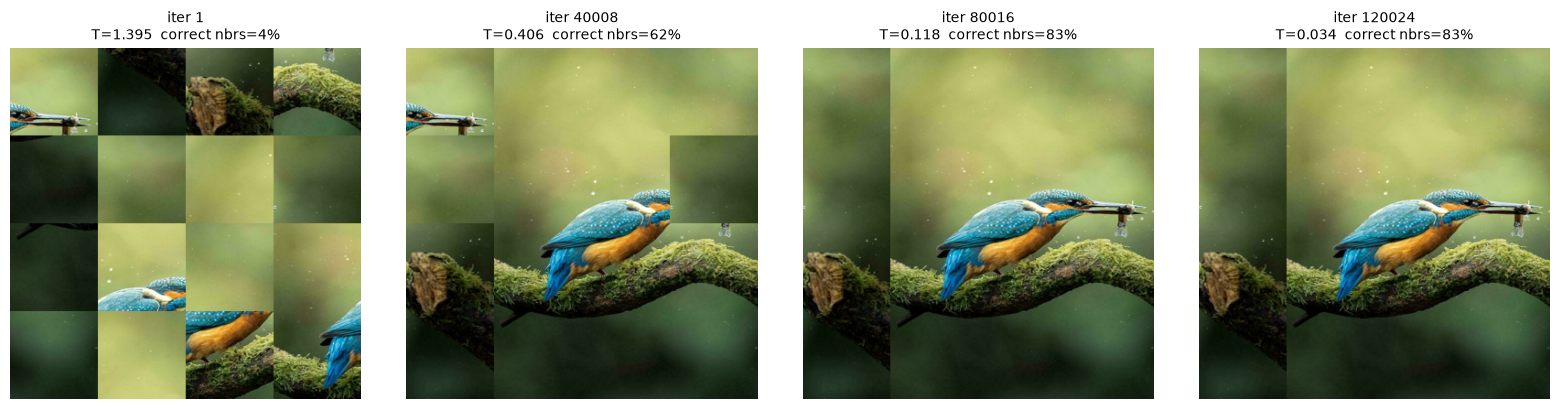

In [69]:
# ---- How the puzzle gets solved during annealing
snaps = sa_info["snaps"]
fig, axes = plt.subplots(1, len(snaps), figsize=(4 * len(snaps), 4))
for ax, (t, T, s) in zip(np.atleast_1d(axes), snaps):
    ax.imshow(assemble(tiles, s, GRID)); ax.axis("off")
    ax.set_title(f"iter {t}\nT={T:.3f}  correct nbrs={problem.neighbours_correct(s)*100:.0f}%", fontsize=10)
plt.tight_layout(); plt.show()

## 6. Benchmark over puzzle sizes and random seeds
Runs both algorithms on several shuffles per puzzle size. Fewer seeds or smaller grids will run faster; increase them for more reliable statistics.

In [ ]:
def run_trial(grid, seed, img_size=384, hc_restarts=10):
    r = np.random.default_rng(seed)
    size = (img_size // grid) * grid
    img = load_image(IMAGE_PATH, size, r)
    prob = JigsawProblem(split_tiles(img, grid), grid)
    init = prob.random_state(r)
    out = {}

    t0 = time.time(); s, _ = hill_climbing(prob, init)
    out["HC"] = (prob.neighbours_correct(s), prob.tiles_in_place(s), time.time() - t0)

    t0 = time.time(); s, _, _ = hill_climbing_restarts(prob, hc_restarts, r)
    out[f"HC x{hc_restarts}"] = (prob.neighbours_correct(s), prob.tiles_in_place(s), time.time() - t0)

    t0 = time.time(); s, _ = simulated_annealing(prob, init, r, n_steps=5000 * prob.n)
    out["SA"] = (prob.neighbours_correct(s), prob.tiles_in_place(s), time.time() - t0)
    return out


GRIDS, SEEDS = [3, 4, 5, 6], [0, 1, 2]
table = {}
for g in GRIDS:
    runs = [run_trial(g, sd) for sd in SEEDS]
    table[g] = {m: np.mean([r[m] for r in runs], axis=0) for m in runs[0]}

print(f"{'grid':>6s} {'method':>10s} {'correct nbrs':>13s} {'tiles in place':>15s} {'time(s)':>9s}")
for g in GRIDS:
    for m, (nb, ip, sec) in table[g].items():
        print(f"{g}x{g:<4d} {m:>10s} {nb*100:12.1f}% {ip*100:14.1f}% {sec:9.2f}")

methods = list(table[GRIDS[0]].keys())
x = np.arange(len(GRIDS)); w = 0.25
plt.figure(figsize=(7, 4))
for k, m in enumerate(methods):
    plt.bar(x + (k - 1) * w, [table[g][m][0] * 100 for g in GRIDS], w, label=m)
plt.xticks(x, [f"{g}x{g}" for g in GRIDS]); plt.ylabel("correct neighbour pairs (%)")
plt.title("Solver quality vs puzzle size (mean over seeds)"); plt.legend(); plt.show()

## 7. Discussion and ideas to extend
- **Hill climbing** is fast but greedy: it stops at the first local maximum, which for jigsaws is typically a layout with correct *clusters* of tiles that are wrongly placed relative to each other. Random restarts help for small puzzles but do not scale.
- **Simulated annealing** accepts worse moves with probability `e^(ΔE/T)`. At high `T` it explores; as `T` falls it settles into a deep optimum. It usually gets far more neighbour pairs right on larger puzzles.
- **"Tiles in place" vs "correct neighbours":** a solution can be a perfectly assembled image that is *shifted* or wrapped, so the neighbour metric is the fairer measure of assembly quality.
- **Tuning tips:** increase `n_steps` (slower cooling) for better results; try `T_min` between 0.001 and 0.05; try a different `T0` (for example 2x the auto value); try other schedules (linear, logarithmic).
- **Extensions:** incremental delta evaluation (only re-score the affected edges); a better compatibility measure (Mahalanobis Gradient Compatibility); allow rotated tiles; try reheating or multiple SA runs.